# First SCF iteration

In [1]:
import numpy as np
from numpy.typing import NDArray

import scipy

import matplotlib.pyplot as plt 

from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.linalg import transformation_matrix
from py_mods.src.external.DIRAC_ME import (
    build_4c_one_Fock_from_h5,
    build_S_V_W_T_from_h5,
    get_nuc_charge,
    full_eri_from_checkpoint,
)
from py_mods.src.SCF.scf_kernels import calc_p_matrix_comp, calc_g_matrix

In [2]:
# load results
He_F0_eigvals = np.loadtxt("files/He_F_eigvals_1st_iter.dat")
He_F1_eigvals = np.loadtxt("files/He_F_eigvals_2nd_iter.dat")
He_F2_eigvals = np.loadtxt("files/He_F_eigvals_3rd_iter.dat")

# Zeroth iteration
We establised in a previous notebook that the zeroth iteration from the bare nucleus approximation is:

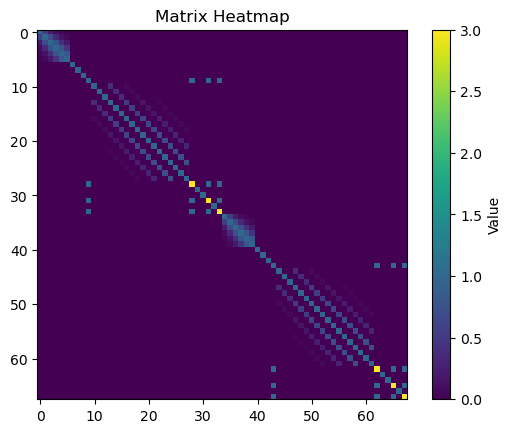

In [ ]:
# Load
h5_filename = "files/H_checkpoint.h5"
F_0 = build_4c_one_Fock_from_h5(h5_filename)
S, V, W, T = build_S_V_W_T_from_h5(h5_filename)
nuc_charge = get_nuc_charge(h5_filename)
eri = full_eri_from_checkpoint(h5_filename)

H_core = T + V + W

X = transformation_matrix(S)

# plot_map(S)

In [4]:
# # Orthogonalization
# X = transformation_matrix(S)

# # Diagonalization
# F_p = X.T @ F_0 @ X
# np.allclose(F_p, F_p.conj().T)

# e, w = scipy.linalg.eig(F_p)

# idx = np.argsort(e)
# e = e[idx]
# w = w[:, idx]


# e_red = [ei for i, ei in enumerate(e) if i % 2 == 0]

In [5]:
# def plot_pos_eigval(e, reference=None, n=0):
#     pos_eigval = [i for i in e.real if i > -0.5 * (137.035999177**2) * 2]
#     # print(pos_eigval)

#     n_LC = len(pos_eigval) // 2
#     n_SC = len(e) // 2 - n_LC

#     e_pairs = [ei for i, ei in enumerate(pos_eigval) if i % 2 == 0]
#     x = [i for i in range(len(e_pairs))]

#     plt.plot(x, e_pairs, label="Computed positive eigval")
#     if reference is not None:
#         plt.plot(x, He_F1_eigvals[-len(x) :], label="Reference positive eigval")
#     plt.title(f"Comparison of computed F{n} positive eigenvalues with reference")
#     plt.xlabel("Index")
#     plt.ylabel("Eigenvalue (Hartree)")
#     plt.legend()
#     plt.show()

# print(f"Eigenvalues are the same for the zeroth iteration: {np.allclose(e_red, He_F0_eigvals)}")
# print(f"Mean absolute error for the zeroth iteration: {np.mean(np.abs(e_red - He_F0_eigvals))}")
# print(f"Max absolute error for the zeroth iteration: {np.max(np.abs(e_red - He_F0_eigvals))}")

# plot_pos_eigval(e, reference=He_F0_eigvals)

In [6]:
# F_diag = np.linalg.inv(w) @ F_p @ w
# plot_map(F_diag)
# plot_map(w)

Now if we wish to transform back it is not as strightforward, as the eigenvectors are now ordered by pairs due to the definition of the 4c equation: 

$$

\begin{bmatrix}
h^{\alpha \alpha} & h^{\alpha \beta} \\
h^{\beta \alpha} & h^{\beta \beta}
\end{bmatrix} 
\begin{bmatrix}
c_{\alpha} \\
c_{\beta} 
\end{bmatrix}

= \varepsilon \begin{bmatrix}
S^{\alpha \alpha} & S^{\alpha \beta} \\
S^{\beta \alpha} & S^{\beta \beta}
\end{bmatrix}
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix}
$$

However, since the eigenvalues are reordered when using `eigh` (or manually in our case), it is necessary to somehow recover the $\alpha/\beta$ eigenvectors and place them in the correct order. For now we are going to assume that the $\alpha$ eigenvectors are the even ones (including zero) and the beta ones are the odd ones. That way, the rearangement of eigenvectors would be: 



In [7]:
# def rearange_eigval_eigvec(eigval, eigvec):
#     """Rearrange the eigenvalues and eigenvectors so alpha and beta spinors are separated."""
#     n_tot = len(eigval)
#     n_alpha = n_tot // 2 - 1

#     rearr_eigvec = np.zeros_like(eigvec)
#     rearr_eigval = np.zeros_like(eigval)

#     for i in range(n_tot):
#         if i % 2 == 0:
#             rearr_eigvec[:, i // 2] = eigvec[:, i]
#             rearr_eigval[i // 2] = eigval[i]

#         if i % 2 != 0:
#             rearr_eigvec[:, n_alpha + i // 2 + 1] = eigvec[:, i]
#             rearr_eigval[n_alpha + i // 2 + 1] = eigval[i]

#     return rearr_eigval, rearr_eigvec

In [8]:
# # w.shape
# # e, w = rearange_eigval_eigvec(e, w)

# plot_map(np.linalg.inv(w) @ F_p @ w)
# plot_map(w)
# print(e)

Where we have separated alpha and beta eigenvectors and have clear blocks. Now it is time to transform back to the original basis by multiplying the eigenvectors with the transformation matrix $X$ as in the regular scf:

$$
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix} =
\begin{bmatrix}
X & 0 \\
0 & X
\end{bmatrix}
\begin{bmatrix}
c_{\alpha}^{\text{orth}} \\
c_{\beta}^{\text{orth}}
\end{bmatrix}
$$

In [9]:
# c_alpha_beta = X @ w

And with this we can try to define occupations. All negative eigenstates will be assumed to be non-occupied:

In [11]:
otherocc = np.zeros(S.shape[0])
otherocc[:] = 0
otherocc[-18] = otherocc[-17] = 1
total_occ_det = otherocc

In [ ]:
def J_LL(P_total, eri_LLLL, eri_LLSS, nL):
    J_LL = np.zeros_like(P_total[:nL, :nL])
    P_LL = P_total[:nL, :nL]
    P_SS = P_total[nL:, nL:]
    J_LL += np.einsum("mnsl, ls -> mn", eri_LLLL, P_LL)
    J_LL += np.einsum("mnsl, ls -> mn", eri_LLSS, P_SS)
    return J_LL


def J_SS(P_total, eri_SSSS, eri_SSLL, nL):
    J_SS = np.zeros_like(P_total[nL:, nL:])
    P_LL = P_total[:nL, :nL]
    P_SS = P_total[nL:, nL:]
    J_SS += np.einsum("mnsl, ls -> mn", eri_SSLL, P_LL)
    J_SS += np.einsum("mnsl, ls -> mn", eri_SSSS, P_SS)
    return J_SS


def g_matrix_4c(P, eri):
    n_bas = P.shape[0]
    n_bas_half = n_bas // 2

    P_aa = P[0:n_bas_half, 0:n_bas_half]
    P_bb = P[n_bas_half:n_bas, n_bas_half:n_bas]
    P_ab = P[0:n_bas_half, n_bas_half:n_bas]
    P_ba = P[n_bas_half:n_bas, 0:n_bas_half]

    P_total = P_aa + P_bb
    # J from total density like in UHF
    J = np.einsum("mnsl, ls -> mn", eri, P_total)

    K_aa = np.einsum("psrq, sr -> pq", eri, P_aa)
    K_bb = np.einsum("psrq, sr -> pq", eri, P_bb)
    K_ab = np.einsum("psrq, sr -> pq", eri, P_ab)
    K_ba = np.einsum("psrq, sr -> pq", eri, P_ba)

    G_aa = J - K_aa
    G_bb = J - K_bb
    # No J as no different spin coulomb

    G_ab = -K_ab
    G_ba = -K_ba

    G_full = np.zeros((n_bas, n_bas), dtype=np.complex128)
    G_full[0:n_bas_half, 0:n_bas_half] = G_aa
    G_full[n_bas_half:n_bas, n_bas_half:n_bas] = G_bb
    G_full[0:n_bas_half, n_bas_half:n_bas] = G_ab
    G_full[n_bas_half:n_bas, 0:n_bas_half] = G_ba

    return G_full


def g_matrix_4c2(P, eri, nL):
    n_bas = P.shape[0]
    n_bas_half = n_bas // 2

    eri_LLLL = eri[:nL, :nL, :nL, :nL]
    eri_LLSS = eri[:nL, :nL, nL:, nL:]
    eri_SSLL = eri[nL:, nL:, :nL, :nL]
    eri_SSSS = eri[nL:, nL:, nL:, nL:]

    P_aa = P[0:n_bas_half, 0:n_bas_half]
    P_bb = P[n_bas_half:n_bas, n_bas_half:n_bas]
    P_ab = P[0:n_bas_half, n_bas_half:n_bas]
    P_ba = P[n_bas_half:n_bas, 0:n_bas_half]

    P_total = P_aa + P_bb

    J_ll = J_LL(P_total, eri_LLLL, eri_LLSS, nL)
    J_ss = J_SS(P_total, eri_SSSS, eri_SSLL, nL)

    J = np.zeros((n_bas, n_bas), dtype=np.complex128)
    J[0:nL, 0:nL] = J[n_bas_half : n_bas_half + nL, n_bas_half : n_bas_half + nL] = J_ll
    J[nL:n_bas_half, nL:n_bas_half] = J[
        n_bas_half + nL : n_bas, n_bas_half + nL : n_bas
    ] = J_ss

    K_aa = np.einsum("psrq, sr -> pq", eri, P_aa)
    K_bb = np.einsum("psrq, sr -> pq", eri, P_bb)
    K_ab = np.einsum("psrq, sr -> pq", eri, P_ab)
    K_ba = np.einsum("psrq, sr -> pq", eri, P_ba)

    G_aa = J[:n_bas_half, :n_bas_half] - K_aa
    G_bb = J[n_bas_half:, n_bas_half:] - K_bb
    # No J as no different spin coulomb

    G_ab = -K_ab
    G_ba = -K_ba

    G_full = np.zeros((n_bas, n_bas), dtype=np.complex128)
    G_full[0:n_bas_half, 0:n_bas_half] = G_aa
    G_full[n_bas_half:n_bas, n_bas_half:n_bas] = G_bb
    G_full[0:n_bas_half, n_bas_half:n_bas] = G_ab
    G_full[n_bas_half:n_bas, 0:n_bas_half] = G_ba

    return G_full

In [ ]:
def scf_iteration(F_1, X, nL, reference=None):
    F_p1 = X.T @ F_1 @ X


    e1, w1 = np.linalg.eigh(F_p1)

    idx = np.argsort(e1)
    e1 = e1[idx]
    w1 = w1[:, idx]

    e1_reduced = [ei for i, ei in enumerate(e1) if i % 2 == 0]

    if reference is not None:
        print(f"Eigenvalues are the same for the first iteration: {np.allclose(e1_reduced, reference)}")
        print(f"Mean absolute error for the first iteration: {np.mean(np.abs(e1_reduced - reference))}")
        print(f"Max absolute error for the first iteration: {np.max(np.abs(e1_reduced - reference))}")
        print(f"Mean absolute error for the first iteration (pos eigvals): {np.mean(np.abs(reference[-nL:] - reference[-nL:]))}")

    c_alpha_beta1 = X @ w1
    P_1 = calc_p_matrix_comp(c_alpha_beta1.conj().T, c_alpha_beta1, total_occ_det)
    # plot_map(P_1)

    return e1, w1, F_p1, P_1

def scf_steps(n_steps):
    for i in range(n_steps):
        if i == 0: 
            G_new = np.zeros_like(H_core)
        else:
            G_new = g_matrix_4c2(P_2, eri, 9)
        F_new = H_core + G_new
        e_new, w_new, F_p_new, P_2 = scf_iteration(F_new, X, nL=9)
        e_scf = np.linalg.trace(P_2 @ H_core + 0.5 * P_2 @ G_new)
        print(f"\n\nSCF energy for iteration {i}: {e_scf.real} Hartree")

# First iteration

In [16]:
scf_steps(15)



SCF energy for iteration 3: -0.99990435300972 Hartree


SCF energy for iteration 4: -0.38553608448389165 Hartree


SCF energy for iteration 5: -0.46391498129092895 Hartree


SCF energy for iteration 6: -0.47213263587799137 Hartree


SCF energy for iteration 7: -0.4733265258088078 Hartree


SCF energy for iteration 8: -0.47352529689811884 Hartree


SCF energy for iteration 9: -0.47356184398874335 Hartree


SCF energy for iteration 10: -0.4735690212485211 Hartree


SCF energy for iteration 11: -0.473570485911477 Hartree


SCF energy for iteration 12: -0.4735707911313951 Hartree


SCF energy for iteration 13: -0.47357085547044586 Hartree


SCF energy for iteration 14: -0.47357086911637725 Hartree


SCF energy for iteration 15: -0.4735708720231747 Hartree


SCF energy for iteration 16: -0.47357087265406517 Hartree


SCF energy for iteration 17: -0.47357087277817955 Hartree


 ref -2.749744636108 

 with first def of j -2.7544181052816548 
with second definition: -2.7544181052816548